# Objective 2.1 — Predicting Match Goal Difference

## Goal

Build and evaluate a linear regression model that predicts the **goal
difference** (`team1_goals - team2_goals`) for each of the **104 matches**
of the 2026 FIFA World Cup, using **8 explanatory variables that are all
knowable before kickoff**.

| # | Variable | Description |
|---|----------|--------------|
| 1 | `rank_diff` | FIFA ranking position difference (team1 − team2; lower rank number = stronger team) |
| 2 | `age_diff` | Squad average-age difference |
| 3 | `value_diff` | Squad market-value difference (EUR m, Transfermarkt) |
| 4 | `titles_diff` | Prior World Cup titles difference (before 2026) |
| 5 | `host_diff` | Host-nation indicator difference (∈ {−1, 0, 1}) |
| 6 | `rest_diff` | Days-of-rest-before-match difference |
| 7 | `same_confed` | 1 if both teams share a confederation, else 0 |
| 8 | `knockout` | 1 if the match is in the knockout stage, else 0 |

None of these variables depend on anything that happens *during* the match
itself (no shots, possession, cards, etc.), satisfying the "available
before the match" requirement.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from data_prep import load_matches, load_teams, build_match_level_dataset

pd.set_option("display.max_columns", None)
np.random.seed(42)

matches = load_matches()
teams = load_teams()
reg_data = build_match_level_dataset(matches, teams)
print(reg_data.shape)
reg_data.head()

(104, 12)


,match_id,team1,team2,goal_diff,rank_diff,age_diff,value_diff,titles_diff,host_diff,rest_diff,same_confed,knockout
0,1,Mexico,South Africa,2,-46,0.6,142.60,0,1,0.0,0,0
1,2,South Korea,Czechia,1,-15,0.4,-49.13,0,0,0.0,0,0
2,3,Canada,Bosnia and Herzegovina,0,-34,0.9,52.25,0,1,0.0,0,0
3,4,USA,Paraguay,3,-24,-2.1,231.95,0,1,0.0,0,0
4,5,Haiti,Scotland,-1,41,-1.7,-114.35,0,0,0.0,0,0


## 1. Sanity checks & exploratory data analysis

In [2]:
assert reg_data.shape[0] == 104, f"Expected 104 rows, got {reg_data.shape[0]}"
feature_cols = [
    "rank_diff", "age_diff", "value_diff", "titles_diff",
    "host_diff", "rest_diff", "same_confed", "knockout",
]
assert len(feature_cols) == 8
print(reg_data[feature_cols + ["goal_diff"]].isna().sum())
reg_data[feature_cols + ["goal_diff"]].describe()

rank_diff      0
age_diff       0
value_diff     0
titles_diff    0
host_diff      0
rest_diff      0
same_confed    0
knockout       0
goal_diff      0
dtype: int64


,rank_diff,age_diff,value_diff,titles_diff,host_diff,rest_diff,same_confed,knockout,goal_diff
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,-7.211538,0.024038,150.483269,0.394231,0.067308,0.115385,0.115385,0.307692,0.480769
std,33.635589,1.471311,562.757484,1.651232,0.375575,0.527086,0.321033,0.463774,2.024034
min,-77.000000,-3.500000,-1366.350000,-5.000000,-1.000000,-1.000000,0.000000,0.000000,-4.000000
25%,-28.500000,-0.925000,-152.525000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
50%,-6.500000,-0.050000,140.765000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,14.000000,1.100000,476.375000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000
max,76.000000,3.200000,1498.800000,5.000000,1.000000,3.000000,1.000000,1.000000,6.000000


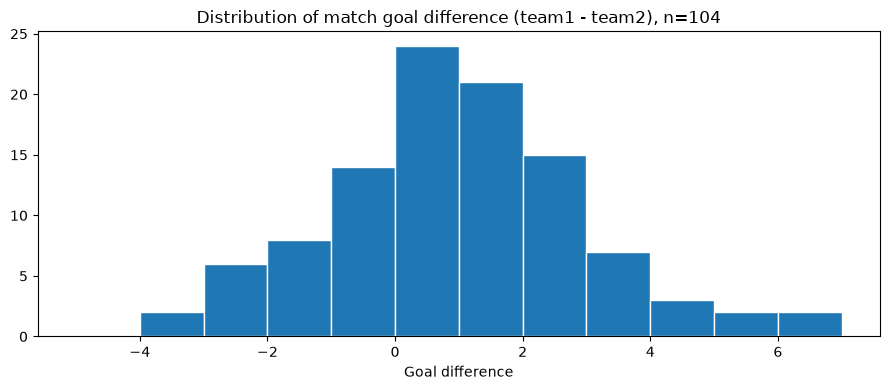

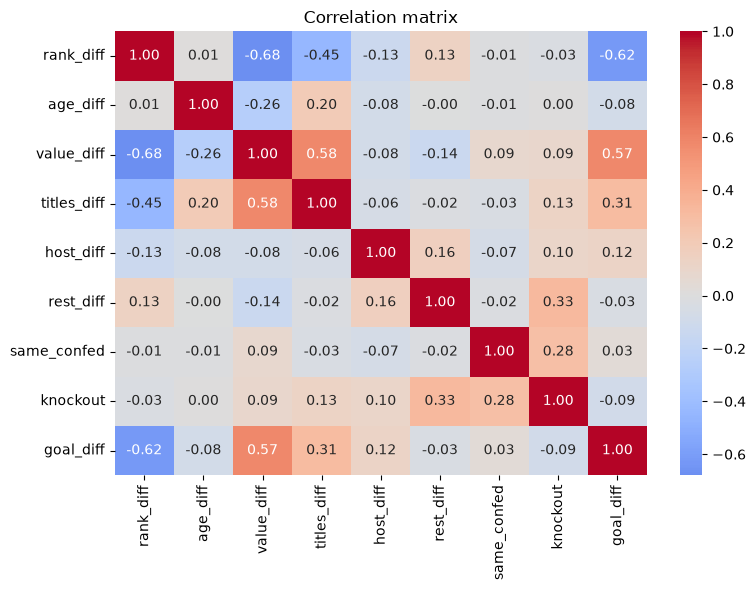

goal_diff      1.000000
value_diff     0.574351
titles_diff    0.308761
host_diff      0.123050
same_confed    0.033331
rest_diff     -0.034302
age_diff      -0.077924
knockout      -0.086721
rank_diff     -0.621121
Name: goal_diff, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(reg_data["goal_diff"], bins=range(int(reg_data["goal_diff"].min()) - 1, int(reg_data["goal_diff"].max()) + 2), edgecolor="white")
ax.set_title("Distribution of match goal difference (team1 - team2), n=104")
ax.set_xlabel("Goal difference")
plt.tight_layout()
plt.savefig("../report/figs/reg1_target_hist.png", dpi=120)
plt.show()

corr = reg_data[feature_cols + ["goal_diff"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig("../report/figs/reg1_corr.png", dpi=120)
plt.show()
corr["goal_diff"].sort_values(ascending=False)

## 2. Multicollinearity check (VIF)

Variance Inflation Factors above ~5–10 would indicate problematic
redundancy among explanatory variables that could inflate coefficient
standard errors.

In [4]:
X_all = sm.add_constant(reg_data[feature_cols])
vif = pd.DataFrame(
    {
        "feature": X_all.columns,
        "VIF": [variance_inflation_factor(X_all.values, i) for i in range(X_all.shape[1])],
    }
)
vif

,feature,VIF
0,const,1.000000
1,rank_diff,2.159281
2,age_diff,1.456159
3,value_diff,3.295447
4,titles_diff,1.951357
5,host_diff,1.144229
6,rest_diff,1.201077
7,same_confed,1.139034
8,knockout,1.285961


## 3. Train/test split

We hold out 20% of matches (≈21 matches) as a test set, purely for
out-of-sample evaluation of predictive performance; the full training set
is then used to fit and interpret the OLS model with `statsmodels`
(coefficients, standard errors, and p-values).

In [5]:
X = reg_data[feature_cols]
y = reg_data["goal_diff"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (83, 8)  Test: (21, 8)


## 4. Fit and interpret the OLS model (training set)

In [6]:
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              goal_diff   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     8.992
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           1.57e-08
Time:                        05:20:04   Log-Likelihood:                -148.92
No. Observations:                  83   AIC:                             315.8
Df Residuals:                      74   BIC:                             337.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1843      0.210      0.877      

## 5. Residual diagnostics

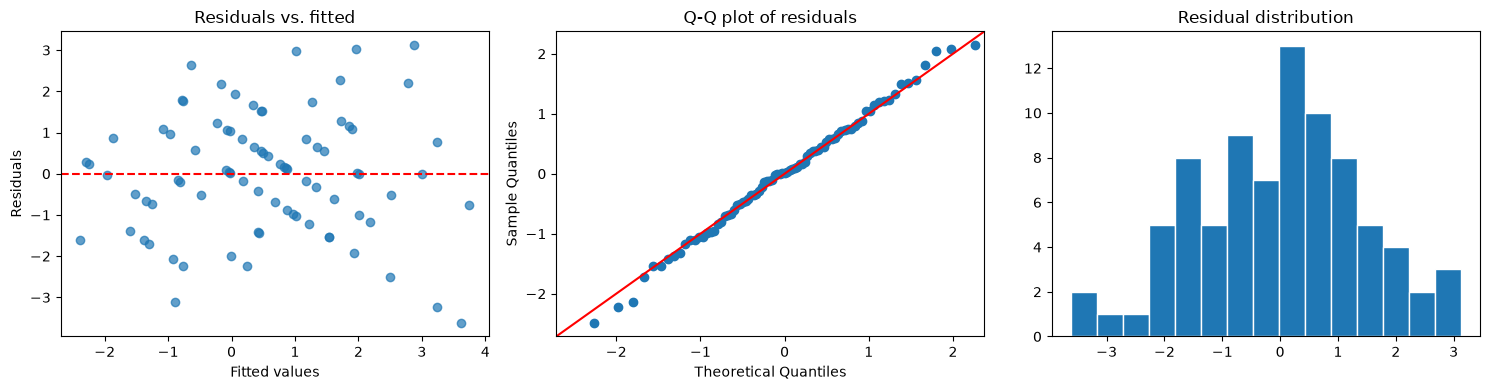

Shapiro-Wilk normality test on residuals: stat=0.9930, p=0.9370


In [7]:
fitted = ols_model.fittedvalues
resid = ols_model.resid

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(fitted, resid, alpha=0.7)
ax[0].axhline(0, color="red", linestyle="--")
ax[0].set_xlabel("Fitted values")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residuals vs. fitted")

sm.qqplot(resid, line="45", fit=True, ax=ax[1])
ax[1].set_title("Q-Q plot of residuals")

ax[2].hist(resid, bins=15, edgecolor="white")
ax[2].set_title("Residual distribution")
plt.tight_layout()
plt.savefig("../report/figs/reg1_diagnostics.png", dpi=120)
plt.show()

from scipy import stats as sstats
shapiro_stat, shapiro_p = sstats.shapiro(resid)
print(f"Shapiro-Wilk normality test on residuals: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

## 6. Out-of-sample evaluation (held-out test matches)

Training R-squared:          0.4929
Training adjusted R-squared: 0.4381
Test R-squared:              0.3064
Test RMSE:                   1.566 goals
Test MAE:                    1.177 goals


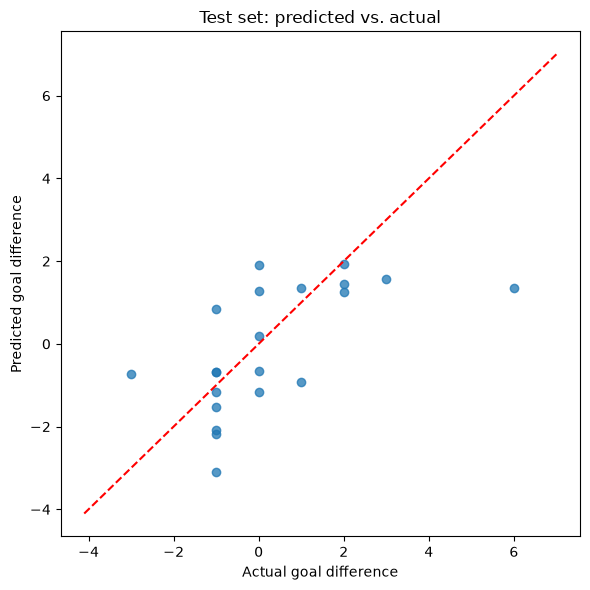

In [8]:
X_test_sm = sm.add_constant(X_test, has_constant="add")[X_train_sm.columns]
y_pred = ols_model.predict(X_test_sm)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

n_train, k = X_train.shape[0], X_train.shape[1]
adj_r2_train = 1 - (1 - ols_model.rsquared) * (n_train - 1) / (n_train - k - 1)

print(f"Training R-squared:          {ols_model.rsquared:.4f}")
print(f"Training adjusted R-squared: {adj_r2_train:.4f}")
print(f"Test R-squared:              {r2_test:.4f}")
print(f"Test RMSE:                   {rmse:.3f} goals")
print(f"Test MAE:                    {mae:.3f} goals")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.75)
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
ax.plot(lims, lims, "r--")
ax.set_xlabel("Actual goal difference")
ax.set_ylabel("Predicted goal difference")
ax.set_title("Test set: predicted vs. actual")
plt.tight_layout()
plt.savefig("../report/figs/reg1_pred_vs_actual.png", dpi=120)
plt.show()

## 7. Conclusion

**Model fit:** the 8-predictor OLS model explains a substantial share of
match-to-match variation in goal difference: **training R² = 0.493**
(adjusted R² = 0.438), and it generalises reasonably to unseen matches
with **test R² = 0.306, RMSE = 1.57 goals, MAE = 1.18 goals** on the
21 held-out matches — respectable given how little separates elite
international sides on any given day.

**Statistically significant predictors (α = 0.05):**
- **`rank_diff`** (coef = −0.0232, p = 0.002): every extra rank position by
  which team1 is *worse* ranked than team2 (i.e. a larger, positive
  `rank_diff`) is associated with about 0.023 fewer net goals for team1 —
  the single most theoretically expected relationship, confirmed.
- **`value_diff`** (coef = +0.0017, p = 0.004): a EUR 1bn squad-value edge
  is associated with roughly **+1.7 extra net goals**, independent of
  ranking — squad market value carries real, additional predictive signal
  beyond the FIFA ranking alone.

**Marginally significant (0.05 < p < 0.10):**
- **`knockout`** (coef = −0.73, p = 0.097): knockout matches trend toward
  *tighter* goal differences than group games, consistent with
  higher-stakes, more cautious tactics in single-elimination football —
  though this falls just short of conventional significance.

**Not significant:** `age_diff`, `titles_diff`, `host_diff`, `rest_diff`,
and `same_confed` did not have a detectable independent linear
relationship with goal difference once ranking and value were accounted
for (their effects, if real, are likely captured indirectly through
`rank_diff`/`value_diff`).

**Diagnostics:** VIFs are all below 3.3 (no problematic multicollinearity
despite the "large condition number" note, which reflects the very
different natural scales of the predictors — e.g. `value_diff` is in the
hundreds while `same_confed` is 0/1 — rather than redundancy). Residuals
are approximately normal (Shapiro–Wilk p = 0.937) and show no obvious
funnel/curvature pattern against fitted values, and the Durbin–Watson
statistic (2.11) shows no autocorrelation concern. The OLS assumptions are
reasonably well satisfied for this model.